/Users/gourasundarmohanty/miniconda3/envs/py313/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1651.91it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


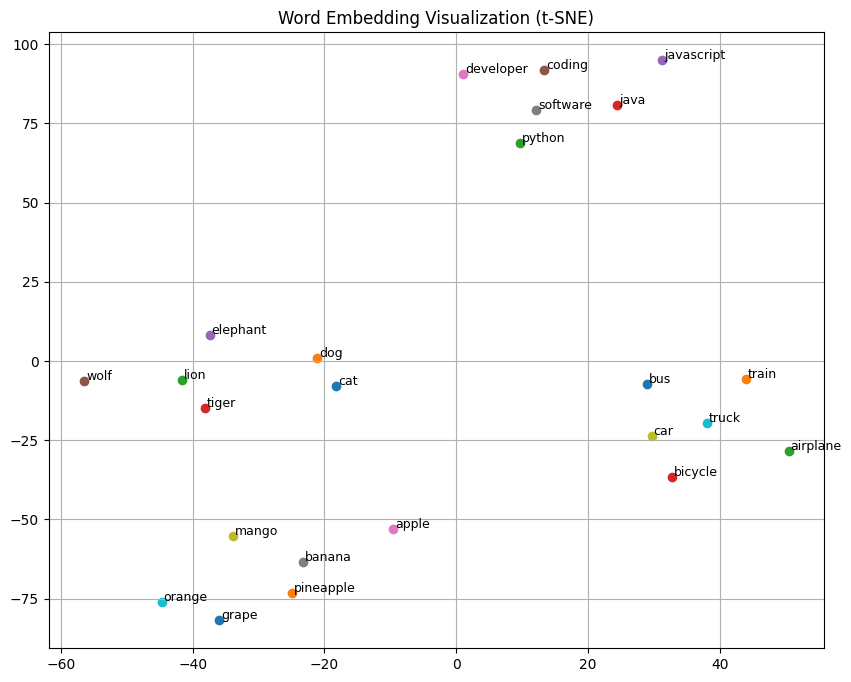

In [1]:
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Load lightweight embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Word groups (intentionally mixed categories)
words = [
    # Animals
    "cat", "dog", "lion", "tiger", "elephant", "wolf",
    
    # Fruits
    "apple", "banana", "mango", "orange", "grape", "pineapple",
    
    # Programming
    "python", "java", "javascript", "coding", "developer", "software",
    
    # Vehicles
    "car", "truck", "bus", "train", "airplane", "bicycle"
]

# Generate embeddings
embeddings = model.encode(words)

# Reduce to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
reduced = tsne.fit_transform(embeddings)

# Plot
plt.figure(figsize=(10, 8))

for i, word in enumerate(words):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x+0.3, y+0.3, word, fontsize=9)

plt.title("Word Embedding Visualization (t-SNE)")
plt.grid(True)
plt.show()